# Simulation: Rote und schwarze Kugeln

In einer Urne liegen $n_1$ rote und $n_2$ schwarze Kugeln. Alle Kugeln werden nacheinander **ohne Zurücklegen** gezogen.

Für den ersten Zug ist unmittelbar klar:

$$
P(\text{1. Zug rot})=\frac{n_1}{n_1+n_2}.
$$

Die Simulation richtet den Blick auf die weiterführende Frage:

> Unterscheiden sich die Zugpositionen hinsichtlich der Wahrscheinlichkeit für eine rote Kugel?

Sie kann eine Vermutung sichtbar machen. Die mathematische Begründung durch die Gleichberechtigung der Positionen ersetzt sie nicht.

## 1. Bibliotheken

In [9]:
from math import comb
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np

plt.rcParams.update({
    "figure.dpi": 120,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
})

## 2. Eingaben

Alle veränderbaren Größen stehen an einer Stelle. Mit `SEED = 42` ist die Simulation reproduzierbar.

In [10]:
# Zusammensetzung der Urne
N_ROT = 2
N_SCHWARZ = 3

# Umfang der Simulation
ANZAHL_SIMULATIONEN = 20_000
ANZAHL_FOLGEN_ANZEIGEN = 15
SEED = 42

# Optionaler Ausblick: Zahl roter Kugeln unter den ersten M Ziehungen
M = 3

# Abbildungen zusätzlich als PNG und PDF speichern?
ABBILDUNGEN_SPEICHERN = False
AUSGABEORDNER = Path("fig")

## 3. Simulation

Eine Zeile des Arrays `ziehungen` beschreibt eine vollständige Ziehungsfolge. Dabei steht `1` für Rot und `0` für Schwarz.

In [11]:
if N_ROT <= 0 or N_SCHWARZ <= 0:
    raise ValueError("N_ROT und N_SCHWARZ müssen positiv sein.")
if ANZAHL_SIMULATIONEN <= 0:
    raise ValueError("ANZAHL_SIMULATIONEN muss positiv sein.")

N_GESAMT = N_ROT + N_SCHWARZ
if not 1 <= M <= N_GESAMT:
    raise ValueError("M muss zwischen 1 und N_ROT + N_SCHWARZ liegen.")

farben = np.concatenate((
    np.ones(N_ROT, dtype=np.int8),
    np.zeros(N_SCHWARZ, dtype=np.int8),
))

rng = np.random.default_rng(SEED)
ziehungen = np.vstack([
    rng.permutation(farben)
    for _ in range(ANZAHL_SIMULATIONEN)
])

p_rot = N_ROT / N_GESAMT
relative_haeufigkeiten = ziehungen.mean(axis=0)

# Standardabweichung einer simulierten relativen Häufigkeit
# an einer festen Zugposition
standardabweichung = np.sqrt(
    p_rot * (1 - p_rot) / ANZAHL_SIMULATIONEN
)

print(f"Theoretische Wahrscheinlichkeit für Rot: {p_rot:.4f}")
print(f"Zahl der simulierten Ziehungsfolgen: {ANZAHL_SIMULATIONEN:,}".replace(",", "."))

Theoretische Wahrscheinlichkeit für Rot: 0.4000
Zahl der simulierten Ziehungsfolgen: 20.000


## 4. Zeilenweise lesen: vollständige Ziehungsfolgen

Jede Zeile zeigt einen vollständigen Versuch. In jeder Zeile liegen genau $n_1$ rote und $n_2$ schwarze Kugeln.

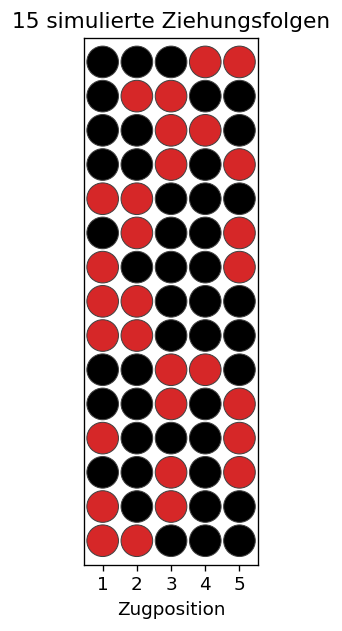

In [18]:
def speichere_abbildung(fig, dateiname):
    """Speichert eine Abbildung bei Bedarf als PNG und als PDF."""
    if ABBILDUNGEN_SPEICHERN:
        AUSGABEORDNER.mkdir(parents=True, exist_ok=True)
        fig.savefig(AUSGABEORDNER / f"{dateiname}.png", dpi=300, bbox_inches="tight")
        fig.savefig(AUSGABEORDNER / f"{dateiname}.pdf", bbox_inches="tight")


anzahl_gezeigt = min(ANZAHL_FOLGEN_ANZEIGEN, ANZAHL_SIMULATIONEN)
folgen = ziehungen[:anzahl_gezeigt]

fig_breite = max(6.0, 0.72 * N_GESAMT)
fig_hoehe = max(3.0, min(11.0, 0.38 * anzahl_gezeigt))
fig, ax = plt.subplots(figsize=(fig_breite, fig_hoehe))

x = np.tile(np.arange(1, N_GESAMT + 1), anzahl_gezeigt)
y = np.repeat(np.arange(1, anzahl_gezeigt + 1), N_GESAMT)
punktfarben = np.where(folgen.ravel() == 1, "tab:red", "black")
punktgroesse = max(35, min(360, 1800 / N_GESAMT))

ax.scatter(
    x,
    y,
    s=punktgroesse,
    c=punktfarben,
    edgecolors="0.25",
    linewidths=0.6,
)
ax.set_xticks(np.arange(1, N_GESAMT + 1))
ax.set_yticks([])
ax.set_xlabel("Zugposition")
ax.set_title(f"{anzahl_gezeigt} simulierte Ziehungsfolgen")
ax.set_xlim(0.45, N_GESAMT + 0.55)
ax.set_ylim(anzahl_gezeigt + 0.7, 0.3)
ax.set_aspect("equal", adjustable="box")

speichere_abbildung(fig, "simulierte_ziehungsfolgen")
plt.show()

## 5. Spaltenweise lesen: Rot an einer festen Zugposition

Nun wird dieselbe Ergebnismatrix spaltenweise gelesen. Für jede Zugposition wird der Anteil der Simulationen bestimmt, in denen dort eine rote Kugel liegt.

Die gestrichelte Linie zeigt

$$
p=\frac{n_1}{n_1+n_2}.
$$

Das blaue Band reicht von $p-1{,}96\sigma$ bis $p+1{,}96\sigma$ mit

$$
\sigma=\sqrt{\frac{p(1-p)}{N}}.
$$

Es beschreibt für jede einzelne Position einen typischen Monte-Carlo-Schwankungsbereich von ungefähr $95\,\%$. Es ist kein simultanes Band für alle Positionen. Die y-Achse zeigt bewusst nur einen Ausschnitt um $p$, damit die zufallsbedingten Abweichungen sichtbar werden.

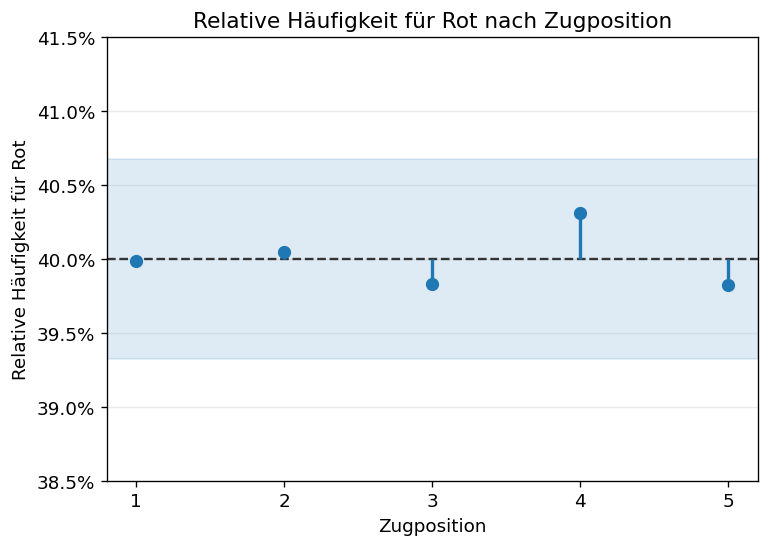

Zugposition   Relative Häufigkeit Rot
      1                    0.3998
      2                    0.4005
      3                    0.3983
      4                    0.4031
      5                    0.3982


In [13]:
positionen = np.arange(1, N_GESAMT + 1)
untere_grenze = max(0.0, p_rot - 1.96 * standardabweichung)
obere_grenze = min(1.0, p_rot + 1.96 * standardabweichung)

fig, ax = plt.subplots(figsize=(max(7.0, 0.65 * N_GESAMT), 4.8))
ax.axhspan(untere_grenze, obere_grenze, color="tab:blue", alpha=0.14)
ax.axhline(p_rot, color="0.2", linestyle="--", linewidth=1.4)
ax.vlines(
    positionen,
    p_rot,
    relative_haeufigkeiten,
    color="tab:blue",
    linewidth=2,
)
ax.scatter(
    positionen,
    relative_haeufigkeiten,
    color="tab:blue",
    s=48,
    zorder=3,
)

# Die y-Achse wird bewusst um p herum vergrößert, damit die
# Monte-Carlo-Schwankungen sichtbar werden.
groesste_abweichung = np.max(np.abs(relative_haeufigkeiten - p_rot))
halbe_hoehe = max(0.015, 1.35 * groesste_abweichung, 2.7 * standardabweichung)
ax.set_ylim(max(0.0, p_rot - halbe_hoehe), min(1.0, p_rot + halbe_hoehe))

ax.set_xticks(positionen)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0, decimals=1))
ax.set_xlabel("Zugposition")
ax.set_ylabel("Relative Häufigkeit für Rot")
ax.set_title("Relative Häufigkeit für Rot nach Zugposition")
ax.grid(axis="y", alpha=0.25)

speichere_abbildung(fig, "relative_haeufigkeit_nach_position")
plt.show()

print("Zugposition   Relative Häufigkeit Rot")
for position, haeufigkeit in zip(positionen, relative_haeufigkeiten):
    print(f"{position:>7d} {haeufigkeit:>25.4f}")

Die Werte sind nicht exakt gleich. Sie schwanken zufallsbedingt um denselben theoretischen Wert. Die Simulation legt daher die Vermutung nahe:

$$
P(\text{Kugel an Position }k\text{ ist rot})
=\frac{n_1}{n_1+n_2}
\qquad\text{für jedes }k.
$$

Nun entsteht die mathematische Frage: **Was hat eine Zugposition, was eine andere nicht hat?**

## 6. Gleichberechtigung ist nicht Unabhängigkeit

Die gleiche Wahrscheinlichkeit für Rot an allen Positionen bedeutet nicht, dass die Farben an den Positionen unabhängig sind. In jeder Zeile steht insgesamt genau $n_1$-mal Rot. Ist an einer Position bereits Rot aufgetreten, verändert sich die Zusammensetzung für die übrigen Positionen.

Die folgende Rechnung vergleicht die Simulation mit der exakten bedingten Wahrscheinlichkeit für die zweite Position.

In [14]:
if N_GESAMT >= 2:
    nach_rot = ziehungen[ziehungen[:, 0] == 1, 1]
    nach_schwarz = ziehungen[ziehungen[:, 0] == 0, 1]

    empirisch_nach_rot = nach_rot.mean()
    empirisch_nach_schwarz = nach_schwarz.mean()
    exakt_nach_rot = (N_ROT - 1) / (N_GESAMT - 1)
    exakt_nach_schwarz = N_ROT / (N_GESAMT - 1)

    print("Wahrscheinlichkeit für Rot an Position 2")
    print(f"nach Rot an Position 1:     Simulation {empirisch_nach_rot:.4f} | exakt {exakt_nach_rot:.4f}")
    print(f"nach Schwarz an Position 1: Simulation {empirisch_nach_schwarz:.4f} | exakt {exakt_nach_schwarz:.4f}")

Wahrscheinlichkeit für Rot an Position 2
nach Rot an Position 1:     Simulation 0.2455 | exakt 0.2500
nach Schwarz an Position 1: Simulation 0.5038 | exakt 0.5000


## 7. Ausblick: Eine neue Verteilung entsteht aus dem Problem

Die Zufallsgröße $X$ zählt die roten Kugeln unter den ersten $M$ Ziehungen. Ihre Wahrscheinlichkeitsverteilung ergibt sich aus dem Urnenproblem:

$$
P(X=k)
=\frac{\binom{n_1}{k}\binom{n_2}{M-k}}
{\binom{n_1+n_2}{M}}.
$$

Die Grafik vergleicht die simulierten relativen Häufigkeiten mit diesen exakten Wahrscheinlichkeiten.

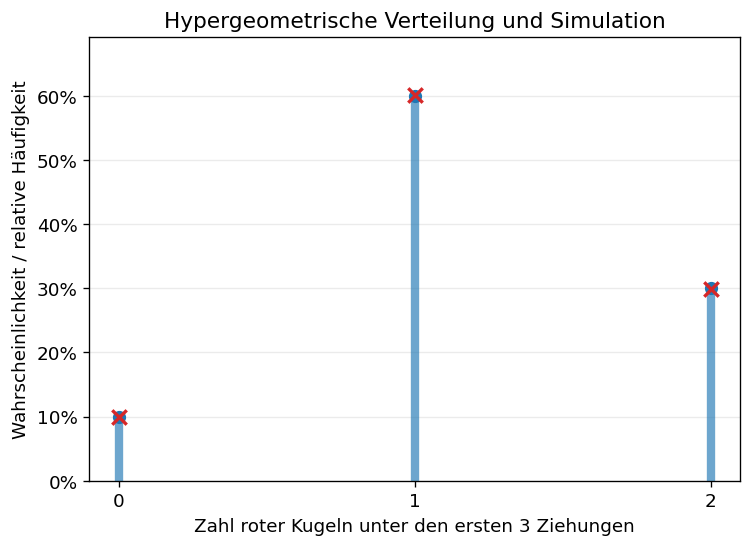

Blau: exakte Wahrscheinlichkeit | Rotes Kreuz: Simulation


In [15]:
anzahl_rot_unter_ersten_m = ziehungen[:, :M].sum(axis=1)
k_min = max(0, M - N_SCHWARZ)
k_max = min(N_ROT, M)
k_werte = np.arange(k_min, k_max + 1)

simulierte_wahrscheinlichkeiten = np.array([
    np.mean(anzahl_rot_unter_ersten_m == k)
    for k in k_werte
])
exakte_wahrscheinlichkeiten = np.array([
    comb(N_ROT, int(k)) * comb(N_SCHWARZ, M - int(k)) / comb(N_GESAMT, M)
    for k in k_werte
])

fig, ax = plt.subplots(figsize=(7.0, 4.8))
ax.vlines(k_werte, 0, exakte_wahrscheinlichkeiten, color="tab:blue", linewidth=5, alpha=0.65)
ax.scatter(k_werte, exakte_wahrscheinlichkeiten, color="tab:blue", s=48, zorder=3)
ax.scatter(k_werte, simulierte_wahrscheinlichkeiten, color="tab:red", marker="x", s=75, linewidths=2, zorder=4)

ax.set_xticks(k_werte)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0, decimals=0))
ax.set_xlabel(f"Zahl roter Kugeln unter den ersten {M} Ziehungen")
ax.set_ylabel("Wahrscheinlichkeit / relative Häufigkeit")
ax.set_title("Hypergeometrische Verteilung und Simulation")
ax.set_ylim(0, min(1.0, 1.15 * max(exakte_wahrscheinlichkeiten.max(), simulierte_wahrscheinlichkeiten.max())))
ax.grid(axis="y", alpha=0.25)

speichere_abbildung(fig, "hypergeometrische_verteilung")
plt.show()

print("Blau: exakte Wahrscheinlichkeit | Rotes Kreuz: Simulation")

Der Erwartungswert allein wäre auch hier nur die halbe Wahrheit. Für die hypergeometrisch verteilte Zufallsgröße $X$ gilt

$$
E(X)=Mp,
\qquad
\operatorname{Var}(X)
=Mp(1-p)\frac{n_1+n_2-M}{n_1+n_2-1}.
$$

Der letzte Faktor ist kleiner als $1$. Die Streuung ist daher kleiner als bei $M$ unabhängigen Bernoulli-Versuchen mit derselben Trefferwahrscheinlichkeit. Auch darin wird sichtbar: **Gleichberechtigung ist nicht Unabhängigkeit.**

In [8]:
erwartungswert_exakt = M * p_rot
varianz_exakt = M * p_rot * (1 - p_rot) * (N_GESAMT - M) / (N_GESAMT - 1)

erwartungswert_simuliert = anzahl_rot_unter_ersten_m.mean()
varianz_simuliert = anzahl_rot_unter_ersten_m.var(ddof=0)

print("                         Simulation      exakt")
print(f"Erwartungswert          {erwartungswert_simuliert:10.4f} {erwartungswert_exakt:10.4f}")
print(f"Varianz                 {varianz_simuliert:10.4f} {varianz_exakt:10.4f}")
print(f"Standardabweichung      {np.sqrt(varianz_simuliert):10.4f} {np.sqrt(varianz_exakt):10.4f}")

                         Simulation      exakt
Erwartungswert              1.1986     1.2000
Varianz                     0.3592     0.3600
Standardabweichung          0.5993     0.6000


## Mögliche Fragen an die Simulation

- Was ist beim zeilenweisen, was beim spaltenweisen Lesen zu erkennen?
- Weshalb stimmen die relativen Häufigkeiten an den Positionen nicht exakt überein?
- Welche Vermutung legt die Grafik nahe – und was kann sie nicht beweisen?
- Woran lässt sich erkennen, dass Gleichberechtigung der Positionen keine Unabhängigkeit bedeutet?
- Welche neue Fragestellung führt von den einzelnen Positionen zur hypergeometrischen Verteilung?